   # University of Gondar
  ## Collage of Informatics
## Department of Information Science
## Msc in Data Science and Analytics
### Advanced Data Mining and Machine Learning Project 2
### Crop Recommendation System Using Machine Learning


#### Eyob Birhanu
#### January 17, 2025

# Implementing my project

## Step 1:- Crop Recommendation System Using Machine Learning

## Step 2:- Source: Kaggle
Size: 2200 instances with 7 features and 1 target

URL: https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset

_N_- ratio of Nitrogen content in soil

_P_- ratio of Phosphorous content in soil

_K_- ratio of Potassium content in soil

_temperature_- temperature in degree Celsius

_humidity_- relative humidity in %

_ph_- ph value of the soil

_rainfall_- rainfall in mm

_label_- crop name for recommendation

# Step 3 Data Preprocessing

## Importing necessary library and dataset
pandas library used for data analysis and manipulation

In [5]:
import pandas as pd               
crop_df=pd.read_csv('crop_recommend.csv')

In [7]:
crop_df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,rice
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,rice
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,rice
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,rice
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107.0,34.0,32.0,26.774637,66.413269,NaN,177.774507,coffee
2196,99.0,15.0,27.0,27.417112,56.636362,6.086922,127.924610,coffee
2197,118.0,33.0,30.0,24.131797,67.225123,6.362608,173.322839,coffee
2198,117.0,32.0,34.0,26.272418,52.127394,6.758793,127.175293,coffee


#### Generate a statistical summary of the numerical columns in the crop_df DataFrame. 
#### This is useful for quickly understanding the distribution and basic statistics of the dataset.

In [10]:
crop_df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2190.000000,2171.000000,2190.000000,2183.000000,2178.000000,2187.000000,2188.000000
mean,50.530594,53.290189,48.055708,25.611556,71.426342,6.469399,103.484698
std,36.930104,32.901733,50.538449,5.072469,22.322092,0.773527,54.989231
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.762243,60.196003,5.970895,64.509670
50%,37.000000,51.000000,32.000000,25.597049,80.473146,6.425931,94.986242
75%,84.000000,68.000000,49.000000,28.561810,89.991490,6.924267,124.220021
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## 3.1. Checking for missing data

### Checking the structure of data

In [14]:
crop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2190 non-null   float64
 1   P            2171 non-null   float64
 2   K            2190 non-null   float64
 3   temperature  2183 non-null   float64
 4   humidity     2178 non-null   float64
 5   ph           2187 non-null   float64
 6   rainfall     2188 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(7), object(1)
memory usage: 137.6+ KB


### Detects and counts missing values

In [17]:
crop_df.isna().sum()

N              10
P              29
K              10
temperature    17
humidity       22
ph             13
rainfall       12
label           0
dtype: int64

In [19]:
crop_df['N'] = crop_df['N'].fillna(crop_df['N'].mean())
crop_df['P']=crop_df['P'].fillna(crop_df['P'].mean())
crop_df['K']=crop_df['K'].fillna(crop_df['K'].mean())
crop_df['temperature']=crop_df['temperature'].fillna(crop_df['temperature'].mean())
crop_df['humidity']=crop_df['humidity'].fillna(crop_df['humidity'].mean())
crop_df['ph']=crop_df['ph'].fillna(crop_df['ph'].mean())
crop_df['rainfall']=crop_df['rainfall'].fillna(crop_df['rainfall'].mean())

In [21]:
crop_df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,rice
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,rice
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,rice
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,rice
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107.0,34.0,32.0,26.774637,66.413269,6.469399,177.774507,coffee
2196,99.0,15.0,27.0,27.417112,56.636362,6.086922,127.924610,coffee
2197,118.0,33.0,30.0,24.131797,67.225123,6.362608,173.322839,coffee
2198,117.0,32.0,34.0,26.272418,52.127394,6.758793,127.175293,coffee


### now check on if missing values is handeled or not

In [24]:
crop_df.isna().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

#### Now we can see that missing values are handled properly, so let's proceed.

## 3.2. Label Encoding

### Check for the type of data that each feature contains

In [29]:
crop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   float64
 1   P            2200 non-null   float64
 2   K            2200 non-null   float64
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(7), object(1)
memory usage: 137.6+ KB


In [31]:
numeric_features = crop_df.select_dtypes(include=['number']).columns.tolist()
non_numeric_features = crop_df.select_dtypes(exclude=['number']).columns.tolist()
text_data_features = crop_df.select_dtypes(include=['object']).columns.tolist()
print("Numeric features:", numeric_features, "\n\nNon_numeric_features:", non_numeric_features, "\n\nText data features:", text_data_features)

Numeric features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'] 

Non_numeric_features: ['label'] 

Text data features: ['label']


### Now we can see that label or crop name column is non numeric, so it needs to be coded into numeric.

In [34]:
crop_df['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

### #Now convert 'label' or crop name 

In [37]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder() # Initialize the LabelEncoder

# Fit and transform the features
crop_df['label'] = label_encoder.fit_transform(crop_df['label'])

### Non-numeric is encoded (transformed)

### Now I am going to check the transformed feature values

In [39]:
numeric_features = crop_df.select_dtypes(include=['number']).columns.tolist()
non_numeric_features = crop_df.select_dtypes(exclude=['number']).columns.tolist()
text_data_features = crop_df.select_dtypes(include=['object']).columns.tolist()
print("Numeric features:", numeric_features, "\n\nNon_numeric_features:", non_numeric_features, "\n\nText data features:", text_data_features)

Numeric features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'] 

Non_numeric_features: [] 

Text data features: []


In [40]:
crop_df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,20
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,20
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,20
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,20
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,20
...,...,...,...,...,...,...,...,...
2195,107.0,34.0,32.0,26.774637,66.413269,6.469399,177.774507,5
2196,99.0,15.0,27.0,27.417112,56.636362,6.086922,127.924610,5
2197,118.0,33.0,30.0,24.131797,67.225123,6.362608,173.322839,5
2198,117.0,32.0,34.0,26.272418,52.127394,6.758793,127.175293,5


In [41]:
crop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   float64
 1   P            2200 non-null   float64
 2   K            2200 non-null   float64
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   int32  
dtypes: float64(7), int32(1)
memory usage: 129.0 KB


### As we can see above, we have no non-numeric or text feature

## 3.3. Data Exploration

### Split the features and target variable

In [45]:
X = crop_df.drop(columns=['label'])
y = crop_df['label']

### Variables correlaton analysis

Correlation between a feature and the target variable

In [52]:
# Compute the correlation matrix
featureCorrWithTarget = X.corrwith(y)

# Display the correlation matrix
print("Correlation between features and target:")
print(featureCorrWithTarget)

Correlation between features and target:
N             -0.030521
P             -0.485684
K             -0.343440
temperature    0.113046
humidity       0.192681
ph            -0.012002
rainfall       0.044575
dtype: float64


### Correlation across the dataset

In [55]:
crop_df.corr()

,N,P,K,temperature,humidity,ph,rainfall,label
N,1.000000,-0.230262,-0.137559,0.027551,0.188411,0.095329,0.058205,-0.030521
P,-0.230262,1.000000,0.725989,-0.133780,-0.120239,-0.139410,-0.060754,-0.485684
K,-0.137559,0.725989,1.000000,-0.160305,0.187660,-0.167639,-0.052022,-0.343440
temperature,0.027551,-0.133780,-0.160305,1.000000,0.207183,-0.019851,-0.033336,0.113046
humidity,0.188411,-0.120239,0.187660,0.207183,1.000000,-0.009867,0.094577,0.192681
ph,0.095329,-0.139410,-0.167639,-0.019851,-0.009867,1.000000,-0.107882,-0.012002
rainfall,0.058205,-0.060754,-0.052022,-0.033336,0.094577,-0.107882,1.000000,0.044575
label,-0.030521,-0.485684,-0.343440,0.113046,0.192681,-0.012002,0.044575,1.000000


### Correlation Heatmap
### A correlation heatmap is a graphical representation of a correlation matrix.
It uses color coding to represent the correlation coefficients, making it easier to visualize the strength and direction of correlations.

Typically, a heatmap uses a color gradient, where darker or more intense colors represent stronger correlations (positive or negative), while lighter colors indicate weaker correlations.

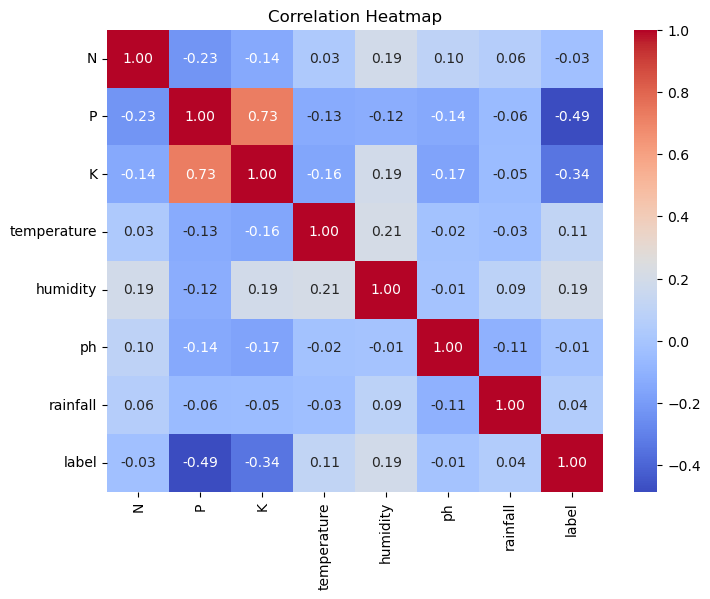

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = crop_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Figuring out feature importances for model building

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=150, random_state=42)
rf.fit(X_train, y_train)

# Get feature importance scores
feature_importance = rf.feature_importances_

# Create a DataFrame for visualization
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})

# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Add a Rank column
importance_df['Rank'] = importance_df.index + 1

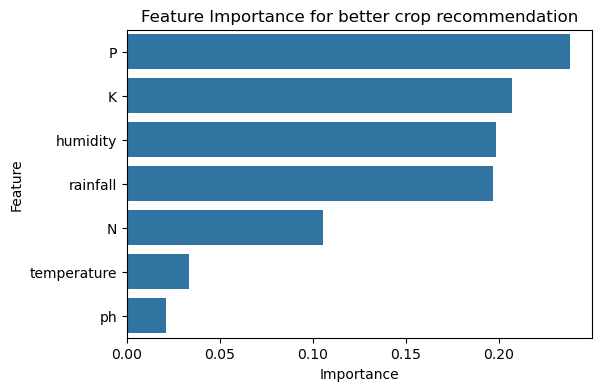

In [63]:
# Plot the feature importance
plt.figure(figsize=(6, 4))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for better crop recommendation')
plt.show()

In [65]:
# Display the DataFrame with ranks
importance_df = importance_df[['Rank', 'Feature', 'Importance']]
importance_df

,Rank,Feature,Importance
0,1,P,0.238022
1,2,K,0.207094
2,3,humidity,0.198564
3,4,rainfall,0.196609
4,5,N,0.105390
5,6,temperature,0.033217
6,7,ph,0.021104


## 3.4. Handling Outliers 

Create a scatter plot for the features in crop_df (excluding the 'charges' column) against the target variable 'charges'. 

The following code will create a scatter plot for each feature in __crop_df__ against the target variable __'label'__ 

Adjust the code according to your DataFrame's structure and the features you want to plot.

Here's how you can do it using Seaborn with different markers:

In [69]:
X.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='object')

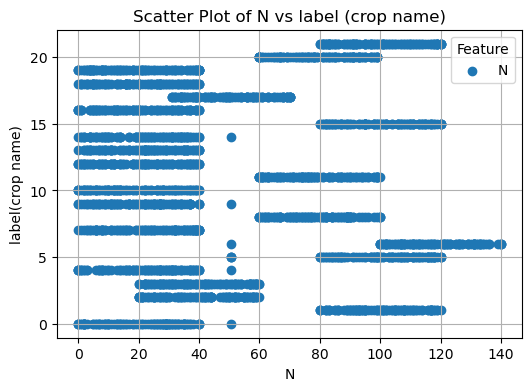

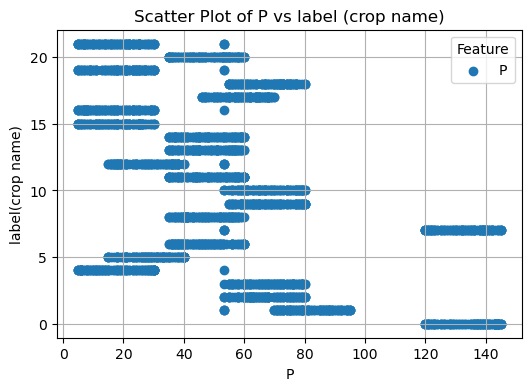

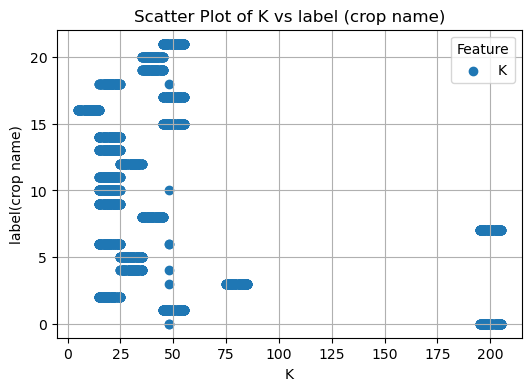

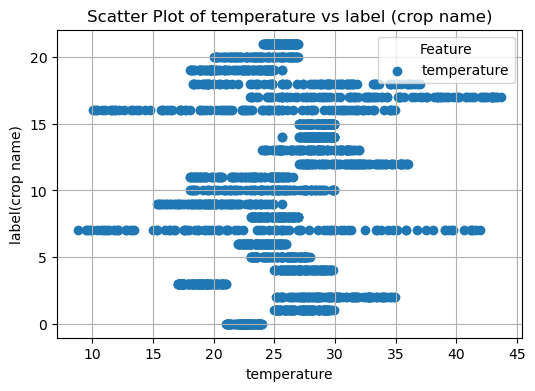

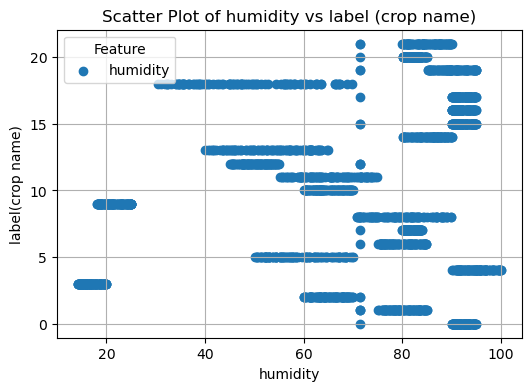

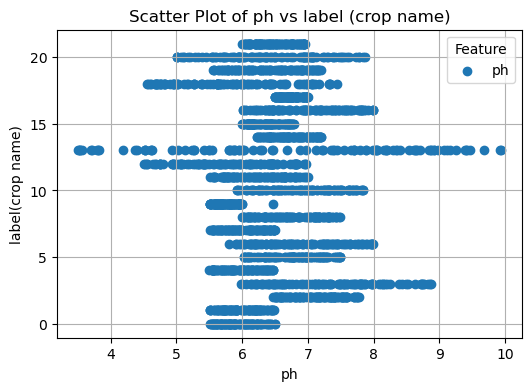

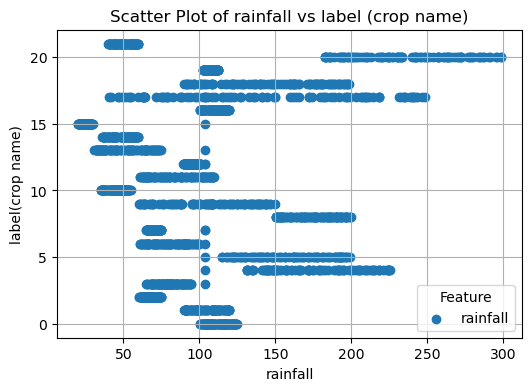

In [71]:
for feature in X.columns:
    plt.figure(figsize=(6, 4))  # Create a new figure for each plot
    
    # Scatter plot using Matplotlib
    plt.scatter(crop_df[feature], crop_df['label'], marker='o', label=feature)
    
    # Add labels, title, and legend
    plt.xlabel(feature)  # Set x-axis label to the feature name
    plt.ylabel('label(crop name)')  # y-axis is 'charges'
    plt.title(f'Scatter Plot of {feature} vs label (crop name)')  # Title for each plot
    plt.legend(title='Feature')  # Add legend
    plt.grid(True)  # Optional: add grid for better readability
    plt.show() 

### Iterate over each feature and create a scatter plot against the target variable

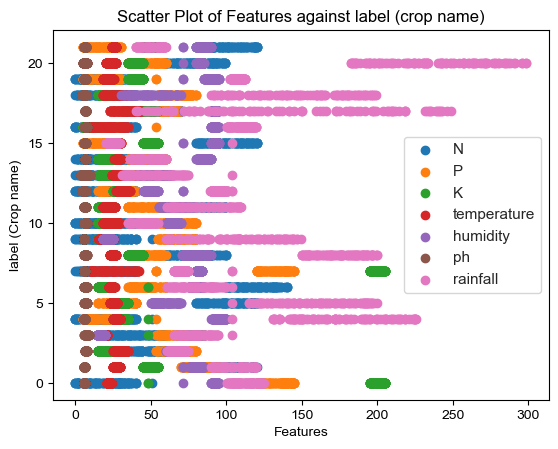

In [73]:
for feature in X.columns:
    plt.scatter(crop_df[feature], crop_df['label'], marker='o', label=feature)

# You can also add additional customization
sns.set(style="whitegrid")
plt.xlabel('Features')
plt.ylabel('label (Crop name)')
plt.title('Scatter Plot of Features against label (crop name)')
plt.legend()
plt.show()

#### As we discussed above, we can use methods like filtering based on statistical properties such as z-score or interquartile range (IQR), or using domain-specific knowledge and discard outliers from a DataFrame. 

#### Here, let's demonstrate how to remove outliers using the IQR method

In [76]:
crop_df.shape

(2200, 8)

In [79]:
def remove_outliers_iqr(X, y):
    # Combine features and target into a single DataFrame
    df = pd.concat([X, y], axis=1)

    # Apply IQR method to remove outliers
    for feature in df.columns:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

    # Split the cleaned DataFrame back into X and y
    X_clean = df[X.columns]
    y_clean = df[y.name]
    
    return X_clean, y_clean

# Assuming crop_df is your dataframe, X and y are already defined
X_clean, y_clean = remove_outliers_iqr(X, y)
crop_df_no_outliers = pd.concat([X_clean, y_clean], axis=1)

# Print the shape of the DataFrame before and after outlier removal
print("Shape of X before outlier removal:", X.shape)
print("Shape of y before outlier removal:", y.shape)
print("Shape of X after outlier removal:", X_clean.shape)
print("Shape of y after outlier removal:", y_clean.shape)

Shape of X before outlier removal: (2200, 7)
Shape of y before outlier removal: (2200,)
Shape of X after outlier removal: (1843, 7)
Shape of y after outlier removal: (1843,)


In [81]:
crop_df_no_outliers

,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,20
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,20
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,20
7,94.0,53.0,40.0,20.277744,82.894086,5.718627,241.974195,20
8,89.0,54.0,38.0,24.515881,83.535216,6.685346,230.446236,20
...,...,...,...,...,...,...,...,...
2195,107.0,34.0,32.0,26.774637,66.413269,6.469399,177.774507,5
2196,99.0,15.0,27.0,27.417112,56.636362,6.086922,127.924610,5
2197,118.0,33.0,30.0,24.131797,67.225123,6.362608,173.322839,5
2198,117.0,32.0,34.0,26.272418,52.127394,6.758793,127.175293,5


In [83]:
X_clean

,N,P,K,temperature,humidity,ph,rainfall
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034
7,94.0,53.0,40.0,20.277744,82.894086,5.718627,241.974195
8,89.0,54.0,38.0,24.515881,83.535216,6.685346,230.446236
...,...,...,...,...,...,...,...
2195,107.0,34.0,32.0,26.774637,66.413269,6.469399,177.774507
2196,99.0,15.0,27.0,27.417112,56.636362,6.086922,127.924610
2197,118.0,33.0,30.0,24.131797,67.225123,6.362608,173.322839
2198,117.0,32.0,34.0,26.272418,52.127394,6.758793,127.175293


In [85]:
y_clean

0       20
1       20
3       20
7       20
8       20
        ..
2195     5
2196     5
2197     5
2198     5
2199     5
Name: label, Length: 1843, dtype: int32

### The scatter plot after the outliers are handled

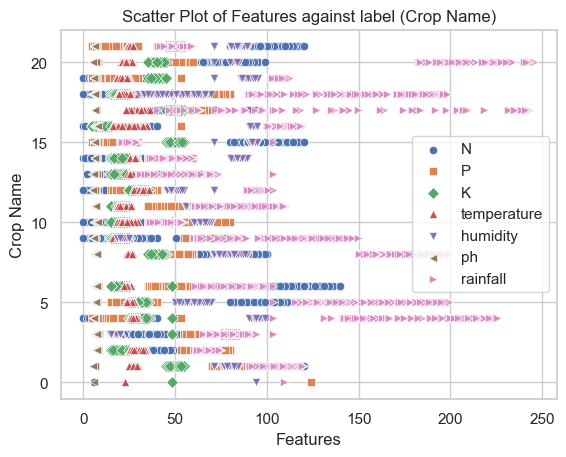

In [88]:
markers = ['o', 's', 'D', '^', 'v', '<', '>']  # Yo can add more markers if you have more features

sns.set(style="whitegrid")

for i, feature in enumerate(X_clean.columns):
    sns.scatterplot(data=crop_df_no_outliers, x=feature, y='label', marker=markers[i % len(markers)], label=feature)

plt.xlabel('Features')
plt.ylabel('Crop Name')
plt.title('Scatter Plot of Features against label (Crop Name)')
plt.legend()
plt.show()

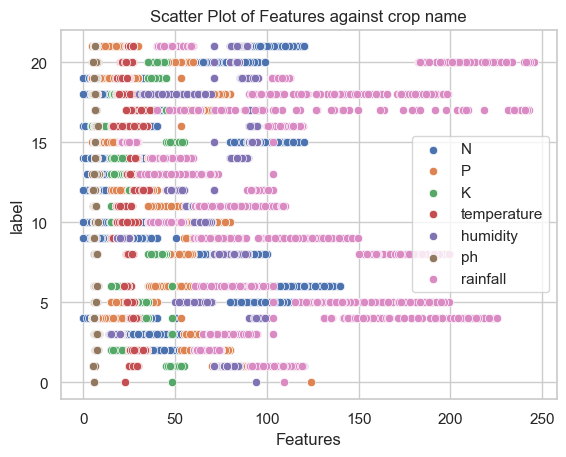

In [89]:
# Iterate over each feature and create a scatter plot against the target variable
for feature in X_clean.columns:
    sns.scatterplot(data= crop_df_no_outliers, x=feature, y='label', marker='o', label=feature)

# You can also add additional customization
sns.set(style="whitegrid")
plt.xlabel('Features')
plt.ylabel('label')
plt.title('Scatter Plot of Features against crop name')
plt.legend()
plt.show()

## 3.5. Standardization and Normalization

### Standardizing features

In [94]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # Initializing the standardization function
X_standardized = scaler.fit_transform(X_clean)

# Convert the scaled data back to a DataFrame
X_standardized_df = pd.DataFrame(X_standardized, columns=X_clean.columns)

# Combine scaled features and target back into a single DataFrame if needed
crop_df_standardized = pd.concat([X_standardized_df, y_clean.reset_index(drop=True)], axis=1)

In [96]:
X_clean

,N,P,K,temperature,humidity,ph,rainfall
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034
7,94.0,53.0,40.0,20.277744,82.894086,5.718627,241.974195
8,89.0,54.0,38.0,24.515881,83.535216,6.685346,230.446236
...,...,...,...,...,...,...,...
2195,107.0,34.0,32.0,26.774637,66.413269,6.469399,177.774507
2196,99.0,15.0,27.0,27.417112,56.636362,6.086922,127.924610
2197,118.0,33.0,30.0,24.131797,67.225123,6.362608,173.322839
2198,117.0,32.0,34.0,26.272418,52.127394,6.758793,127.175293


In [98]:
X_standardized_df

,N,P,K,temperature,humidity,ph,rainfall
0,0.946288,-0.146333,0.614848,-1.165829,0.544001,0.015374,1.957060
1,0.814262,0.568203,0.494346,-0.950163,0.469530,0.805890,2.413470
2,0.523807,-0.458942,0.434096,0.192824,0.462394,0.720657,2.725347
3,1.051908,0.344911,0.434096,-1.311588,0.583440,-1.143352,2.708225
4,0.919883,0.389569,0.313594,-0.285426,0.611808,0.284775,2.486409
...,...,...,...,...,...,...,...
1838,1.395174,-0.503600,-0.047910,0.261477,-0.145779,-0.034243,1.472922
1839,1.183933,-1.352111,-0.349163,0.417036,-0.578374,-0.599272,0.513732
1840,1.685630,-0.548259,-0.168411,-0.378423,-0.109857,-0.192004,1.387265
1841,1.659225,-0.592917,0.072592,0.139877,-0.777880,0.393276,0.499314


In [100]:
y_clean

0       20
1       20
3       20
7       20
8       20
        ..
2195     5
2196     5
2197     5
2198     5
2199     5
Name: label, Length: 1843, dtype: int32

In [102]:
crop_df_standardized

,N,P,K,temperature,humidity,ph,rainfall,label
0,0.946288,-0.146333,0.614848,-1.165829,0.544001,0.015374,1.957060,20
1,0.814262,0.568203,0.494346,-0.950163,0.469530,0.805890,2.413470,20
2,0.523807,-0.458942,0.434096,0.192824,0.462394,0.720657,2.725347,20
3,1.051908,0.344911,0.434096,-1.311588,0.583440,-1.143352,2.708225,20
4,0.919883,0.389569,0.313594,-0.285426,0.611808,0.284775,2.486409,20
...,...,...,...,...,...,...,...,...
1838,1.395174,-0.503600,-0.047910,0.261477,-0.145779,-0.034243,1.472922,5
1839,1.183933,-1.352111,-0.349163,0.417036,-0.578374,-0.599272,0.513732,5
1840,1.685630,-0.548259,-0.168411,-0.378423,-0.109857,-0.192004,1.387265,5
1841,1.659225,-0.592917,0.072592,0.139877,-0.777880,0.393276,0.499314,5


### Save the standardised data frames (X_standardized_df and crop_df_standardized) and a data series (y) to CSV - 

In [105]:
X_standardized_df.to_csv('crop_df_f.csv', index=False)

y_clean.to_csv('crop_df_t.csv', index=False)

crop_df_standardized.to_csv('crop_df_standard.csv', index=False)

# Step 4  Model Building

### Load the features and target data

In [109]:
Xn = pd.read_csv('crop_df_f.csv')
yn = pd.read_csv('crop_df_t.csv')

# Optional: Check the first few rows of the data to confirm
print(Xn.head())
print(yn.head())


          N         P         K  temperature  humidity        ph  rainfall
0  0.946288 -0.146333  0.614848    -1.165829  0.544001  0.015374  1.957060
1  0.814262  0.568203  0.494346    -0.950163  0.469530  0.805890  2.413470
2  0.523807 -0.458942  0.434096     0.192824  0.462394  0.720657  2.725347
3  1.051908  0.344911  0.434096    -1.311588  0.583440 -1.143352  2.708225
4  0.919883  0.389569  0.313594    -0.285426  0.611808  0.284775  2.486409
   label
0     20
1     20
2     20
3     20
4     20


### Split data into training and testing sets (80% training, 20% testing)

In [112]:
X_train, X_test, y_train, y_test = train_test_split(Xn, yn, test_size=0.2, random_state=42, shuffle=True)

# Optional: Check the shape of the splits
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1474, 7) (369, 7) (1474, 1) (369, 1)


### TRAIN USING Support Vector Machine

In [140]:
# Save this code into train_model.py
code = """
from sklearn.svm import SVC

# Initialize and train SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)
"""

with open("svm_train_model.py", "w") as f:
    f.write(code)

### PREDICTING AND EVALUATING SVM MODEL

In [142]:
# Save SVM prediction and evaluation code into predict.py
code = """
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predict and evaluate
svm_predictions = svm_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, svm_predictions)
acc = accuracy_score(y_test, svm_predictions)

print("Confusion Matrix:\\n", cm)
print("SVM Accuracy:", acc)
print("SVM Classification Report:\\n", classification_report(y_test, svm_predictions))

# --- Plot Confusion Matrix ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=300)
plt.close()  # Close the plot

# --- Plot Accuracy Chart ---
plt.figure(figsize=(5, 4))
plt.bar(['SVM'], [acc], color='green')
plt.ylim(0, 1)
plt.title('SVM Model Accuracy')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.savefig('svm_accuracy_chart.png', dpi=300)
plt.close()
"""

with open("svm_predict.py", "w") as f:
    f.write(code)


### TRAIN USING DECISION TREE MODEL

In [145]:
# Save Decision Tree training code into train_model.py
code = """
from sklearn.tree import DecisionTreeClassifier

# Initialize and train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=10)
dt_model.fit(X_train, y_train)
"""

with open("dt_train_model.py", "w") as f:
    f.write(code)


### PREDICTING AND EVALUATING DECISION TREE MODEL

In [147]:
# Save Decision Tree prediction and evaluation code into predict.py
code = """
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predict and evaluate
dt_predictions = dt_model.predict(X_test)

# Confusion Matrix and Accuracy
cm = confusion_matrix(y_test, dt_predictions)
acc = accuracy_score(y_test, dt_predictions)

print("Confusion Matrix:\\n", cm)
print("Decision Tree Accuracy:", acc)
print("Decision Tree Classification Report:\\n", classification_report(y_test, dt_predictions))

# --- Plot and Save Confusion Matrix ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.savefig('decision_tree_confusion_matrix.png', dpi=300)
plt.close()

# --- Plot and Save Accuracy Chart ---
plt.figure(figsize=(5, 4))
plt.bar(['Decision Tree'], [acc], color='orange')
plt.ylim(0, 1)
plt.title('Decision Tree Model Accuracy')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.savefig('decision_tree_accuracy_chart.png', dpi=300)
plt.close()
"""

with open("dt_predict.py", "w") as f:
    f.write(code)


### TRAIN USING RANDOM FOREST MODEL

In [149]:
# Save Random Forest training code into train_model.py
code = """
from sklearn.ensemble import RandomForestClassifier

# Initialize and train Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
"""

with open("rf_train_model.py", "w") as f:
    f.write(code)


### PREDICTING AND EVALUATING RANDOM FOREST MODEL

In [151]:
# Save Random Forest prediction and evaluation code into predict.py
code = """
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions
rf_pred = model.predict(X_test)

# Confusion Matrix and Accuracy
cm = confusion_matrix(y_test, rf_pred)
acc = accuracy_score(y_test, rf_pred)

print("Confusion Matrix:\\n", cm)
print("Random Forest Accuracy:", acc)
print("Random Forest Classification Report:\\n", classification_report(y_test, rf_pred))

# --- Plot and Save Confusion Matrix ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.savefig('random_forest_confusion_matrix.png', dpi=300)
plt.close()

# --- Plot and Save Accuracy Chart ---
plt.figure(figsize=(5, 4))
plt.bar(['Random Forest'], [acc], color='purple')
plt.ylim(0, 1)
plt.title('Random Forest Model Accuracy')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.savefig('random_forest_accuracy_chart.png', dpi=300)
plt.close()
"""

with open("rf_predict.py", "w") as f:
    f.write(code)


# The end for the time being!!!